# Running the QLD cleaning module
- cleans demand data from metropolitan Brisbane (QLD)
- processes it with the metadata
- saves cleaned data into /home/565/pv3484/aus_substation_electricity/data/cleaned_data/QLD

# Running the VIC cleaning module
- cleans demand data from metropolitan Brisbane (QLD)
- processes it with the metadata
- saves cleaned data into /home/565/pv3484/aus_substation_electricity/data/cleaned_data/QLD

## Getting the correct location for path finding

In [23]:
%pwd

%cd /home/565/pv3484/aus_substation_electricity/data/cleaned_data

/g/data/ng72/pv3484/substation_data/cleaned_data


## This runs the module and cleans the VIC data, and outputs it into the folder

In [24]:
import sys
from pathlib import Path

# Tell Python where your VIC_cleaning.py module lives
sys.path.append("/home/565/pv3484/aus_substation_electricity/cleaning_data")

import VIC_cleaning as vic

# Absolute paths to your data
raw_vic_dir = Path("/home/565/pv3484/aus_substation_electricity/data/raw_data/VIC_demand")
metadata_path = Path("/home/565/pv3484/aus_substation_electricity/data/DNSP_Zone_Substation_Characteristics.csv")
output_root = Path("/home/565/pv3484/aus_substation_electricity/data/cleaned_data/VIC")

# Run cleaning
vic.save_cleaned_state_VIC(
    state_dir=raw_vic_dir,
    metadata_path=metadata_path,
    output_root=output_root,
    sigma=None,
    remove_constant=False,
    fill_small_gaps=False,
    max_gap=4,
    landuse_filters=None
)

print("VIC cleaning complete.")

/home/565/pv3484/aus_substation_electricity/cleaning_data/VIC_cleaning.py:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
/home/565/pv3484/aus_substation_electricity/cleaning_data/VIC_cleaning.py:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[time_col] = pd.to_datetime(df[time_col], errors="coerce")


VIC cleaning complete.


## Cleaned data has many N/As
- trying to find and fix

In [33]:
import pandas as pd
raw = pd.read_csv("/home/565/pv3484/aus_substation_electricity/data/raw_data/VIC_demand/AusNet_VIC/collated_deduplicated_ausnet_2011_mw_30min.csv")
raw.head()

,StartDeliveryTime,EndDeliveryTime,UtilityName,'BDL'|'Bairnsdale Zone Substation'|ActivePower,'BGE'|'Belgrave Zone Substation'|ActivePower,'BN'|'Benalla Zone Substation'|ActivePower,'BRA'|'Boronia Zone Substation'|ActivePower,'BRT'|'Bright Zone Substation'|ActivePower,'BWA'|'Barnawartha Zone Substation'|ActivePower,'BWN'|'Berwick North Zone Substation'|ActivePower,...,'SLE'|'Sale Zone Substation'|ActivePower,'SMR'|'Seymour Zone Substation'|ActivePower,'TGN'|'Traralgon Zone Substation'|ActivePower,'TT'|'Thomastown Zone Substation'|ActivePower,'WGI'|'Wonthaggi Zone Substation'|ActivePower,'WGL'|'Warragul Zone Substation'|ActivePower,'WN'|'Wangaratta Zone Substation'|ActivePower,'WO'|'Wodonga Zone Substation'|ActivePower,'WT'|'Watsonia Zone Substation'|ActivePower,'WYK'|'Woori Yallock Zone Substation'|ActivePower
0,2011-01-01 00:00:00,2011-01-01 00:30:00,AusNet,36.93,16.15,17.07,27.91,5.55,5.37,6.79,...,14.70,18.69,18.63,33.8,20.85,31.86,24.72,20.35,31.58,18.46
1,2011-01-01 00:30:00,2011-01-01 01:00:00,AusNet,36.12,15.94,16.11,26.72,5.52,5.28,6.77,...,14.43,18.24,18.09,33.1,19.87,31.44,23.94,20.20,28.56,18.33
2,2011-01-01 01:00:00,2011-01-01 01:30:00,AusNet,32.70,14.06,14.61,25.03,5.34,5.31,7.00,...,10.94,16.65,16.86,30.7,18.00,30.39,21.90,19.30,26.71,15.61
3,2011-01-01 01:30:00,2011-01-01 02:00:00,AusNet,30.84,12.98,13.56,23.38,5.67,5.43,6.45,...,13.32,15.93,15.86,29.2,16.08,29.37,20.70,19.00,19.38,14.21
4,2011-01-01 02:00:00,2011-01-01 02:30:00,AusNet,45.36,16.25,18.45,23.52,8.26,5.94,7.11,...,15.03,20.13,18.42,28.6,23.19,34.80,26.94,19.95,24.24,18.89


In [26]:
raw.isna().mean()

StartDeliveryTime                                     0.000000
EndDeliveryTime                                       0.000000
UtilityName                                           0.000000
'BDL'|'Bairnsdale Zone Substation'|ActivePower        0.011187
'BGE'|'Belgrave Zone Substation'|ActivePower          0.000000
'BN'|'Benalla Zone Substation'|ActivePower            0.000000
'BRA'|'Boronia Zone Substation'|ActivePower           0.000228
'BRT'|'Bright Zone Substation'|ActivePower            0.000228
'BWA'|'Barnawartha Zone Substation'|ActivePower       0.000228
'BWN'|'Berwick North Zone Substation'|ActivePower     0.000228
'BWR'|'Bayswater Zone Substation'|ActivePower         0.000228
'CLN'|'Clyde North Zone Substation'|ActivePower       0.000228
'CNR'|'Cann River Zone Substation'|ActivePower        0.000228
'CYN'|'Croydon Zone Substation'|ActivePower           0.000228
'DRN'|'Doreen Zone Substation'|ActivePower            0.000228
'ELM'|'Eltham Zone Substation'|ActivePower            0

In [29]:
raw_vic_dir = Path("/home/565/pv3484/aus_substation_electricity/data/raw_data/VIC_demand")
list(raw_vic_dir.glob("**/*.csv"))[:10]

[PosixPath('/home/565/pv3484/aus_substation_electricity/data/raw_data/VIC_demand/CitiPower_VIC/collated_standardized_citipower_2014_mw_30min.csv'),
 PosixPath('/home/565/pv3484/aus_substation_electricity/data/raw_data/VIC_demand/CitiPower_VIC/collated_standardized_citipower_2016_mw_30min.csv'),
 PosixPath('/home/565/pv3484/aus_substation_electricity/data/raw_data/VIC_demand/CitiPower_VIC/collated_standardized_citipower_2017_mw_30min.csv'),
 PosixPath('/home/565/pv3484/aus_substation_electricity/data/raw_data/VIC_demand/CitiPower_VIC/collated_standardized_citipower_2013_mw_30min.csv'),
 PosixPath('/home/565/pv3484/aus_substation_electricity/data/raw_data/VIC_demand/CitiPower_VIC/collated_standardized_citipower_2012_mw_30min.csv'),
 PosixPath('/home/565/pv3484/aus_substation_electricity/data/raw_data/VIC_demand/CitiPower_VIC/collated_standardized_citipower_2006_mw_30min.csv'),
 PosixPath('/home/565/pv3484/aus_substation_electricity/data/raw_data/VIC_demand/CitiPower_VIC/collated_standard

## Looking at the new cleaned demand file
- looking to see if the data did get cleaned and the file can be used

In [ ]:
import pandas as pd
from pathlib import Path

project_root = Path("/home/565/pv3484/aus_substation_electricity")

vic_demand_path = project_root / "data" / "cleaned_data" / "VIC" / "demand.csv"
vic_meta_path   = project_root / "data" / "cleaned_data" / "VIC" / "metadata.csv"

demand_vic = pd.read_csv(vic_demand_path, index_col=0, parse_dates=True)
meta_vic   = pd.read_csv(vic_meta_path)

demand_vic.head[1]

## Creating basic plot of all substation demand data on Aus Day for every year
- testing to see if the data is showing expected patterns

In [30]:
from pathlib import Path
Path("/home/565/pv3484/aus_substation_electricity/data/cleaned_data/VIC/demand.csv").exists()

True

In [31]:
aus = demand_vic.loc[demand_vic.index.strftime("%m-%d") == "01-26"]
aus.count().sort_values()

YVE.9       0
KLO.2       0
MDA.3       0
DVY.12      0
LVN22.3     0
           ..
DVY.1      48
DSH.1      48
DN.1       48
DC.1       48
WPD.13     48
Length: 2156, dtype: int64

/jobfs/158068082.gadi-pbs/ipykernel_940047/3080937145.py:43: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  end=df.index.min().floor("D") + pd.Timedelta("23H"),
/jobfs/158068082.gadi-pbs/ipykernel_940047/3080937145.py:41: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_ticks = pd.date_range(


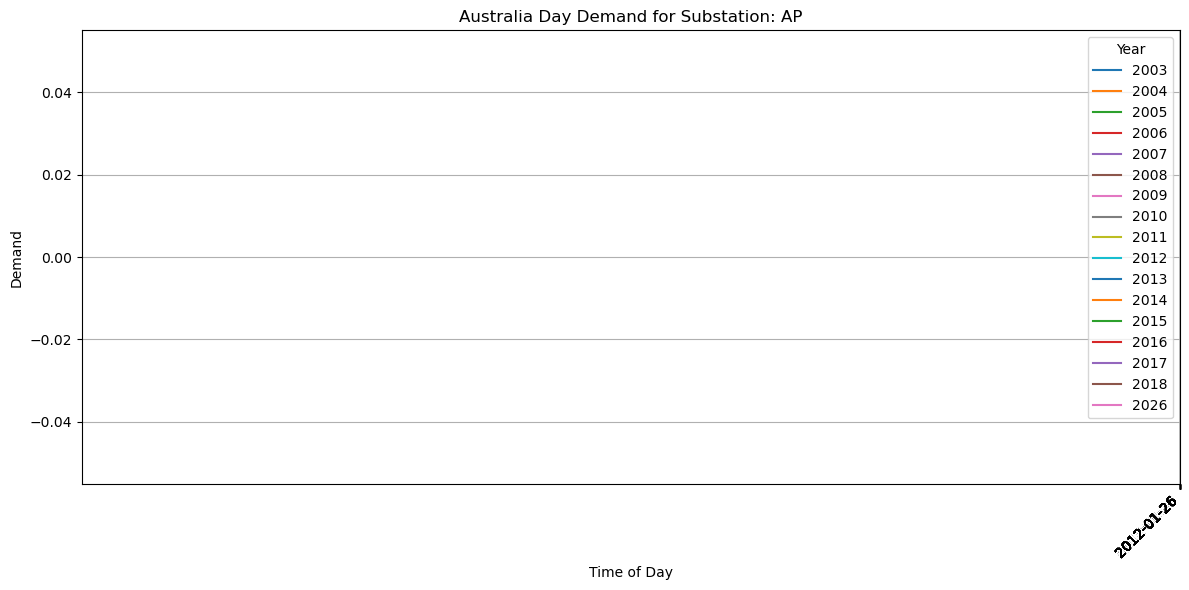

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Load cleaned VIC demand
vic_demand_path = Path("/home/565/pv3484/aus_substation_electricity/data/cleaned_data/VIC/demand.csv")
demand_vic = pd.read_csv(vic_demand_path, index_col=0, parse_dates=True)

# ---------------------------------------------------------
# Extract Australia Day for each year
# ---------------------------------------------------------

ausday_data = {}

for year in sorted(demand_vic.index.year.unique()):
    try:
        ausday_data[year] = demand_vic.loc[f"{2012}-01-26"]
    except KeyError:
        continue

# ---------------------------------------------------------
# Select the first substation
# ---------------------------------------------------------

substation = demand_vic.columns[0]

# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------

plt.figure(figsize=(12,6))

for year, df in ausday_data.items():
    plt.plot(df.index, df[substation], label=str(year))

plt.title(f"Australia Day Demand for Substation: {substation}")
plt.ylabel("Demand")
plt.xlabel("Time of Day")

# Hourly ticks for 24 hours
hourly_ticks = pd.date_range(
    start=df.index.min().floor("D"),
    end=df.index.min().floor("D") + pd.Timedelta("23H"),
    freq="1H"
)
plt.xticks(ticks=hourly_ticks, rotation=45, ha="right")

plt.grid(True)
plt.legend(title="Year")
plt.tight_layout()
plt.show()